
# 02 — Radiation Models and Directivity

This notebook compares the two current radiation models:

- **Monopole**: compact source, no spatial directivity.
- **Baffled circular piston**: Rayleigh surface integral over a rigid piston.

The electromechanical model is unchanged. Radiation remains an **output-only** mapping and does not feed back into the mechanical impedance.


In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")

from src.constants import AIR
from src.components.driver import Driver
from src.components.enclosure import SealedBox
from src.components.radiation import MonopoleRadiation, BaffledCircularPiston
from src.system import LoudspeakerSystem
from src.utils import magnitude_to_db

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


## System setup

The piston radius is obtained from the effective cone area,

$a=\sqrt{\frac{S_d}{\pi}}$,

and the relevant dimensionless parameter for directivity is

$ka=\frac{2\pi f a}{c}$.

When $ka\ll1$, the piston is acoustically compact and should approach the monopole result.


In [2]:
driver = Driver.from_thiele_small(
    Re=3.4,
    Le=1.43e-3,
    Fs=35.7,
    Qms=6.620,
    Qes=0.360,
    Vas=12.10e-3,
    Sd=124.7e-4,
    Xmax=6e-3,
    Pe=100,
)

box = SealedBox(volume=3.68e-3)

monopole = MonopoleRadiation()

piston = BaffledCircularPiston(
    n_radial=40,
    n_angular=80,
)

sealed_monopole = LoudspeakerSystem(
    driver=driver,
    enclosure=box,
    radiation=monopole,
)

sealed_piston = LoudspeakerSystem(
    driver=driver,
    enclosure=box,
    radiation=piston,
)

freqs = np.logspace(1, 4, 1000)
voltage = 1.0
distance = 1.0

a = np.sqrt(driver.Sd / np.pi)
f_ka1 = AIR.speed_of_sound / (2 * np.pi * a)

print(f"Equivalent piston radius: {100*a:.2f} cm")
print(f"ka = 1 at approximately: {f_ka1:.0f} Hz")

Equivalent piston radius: 6.30 cm
ka = 1 at approximately: 868 Hz



# Experiment 1 — Monopole vs. finite piston

The monopole pressure is

$p(r,\omega)=\frac{j\omega\rho_0 U}{2\pi r}e^{-jkr}$.

For the baffled piston,

$p(\mathbf{x},\omega)=\frac{j\rho_0\omega v}{2\pi}\int_S\frac{e^{-jkR}}{R}\,dS$.

On axis and at low \(ka\), the piston should approach the monopole. Off axis, finite-source interference becomes visible as frequency increases.


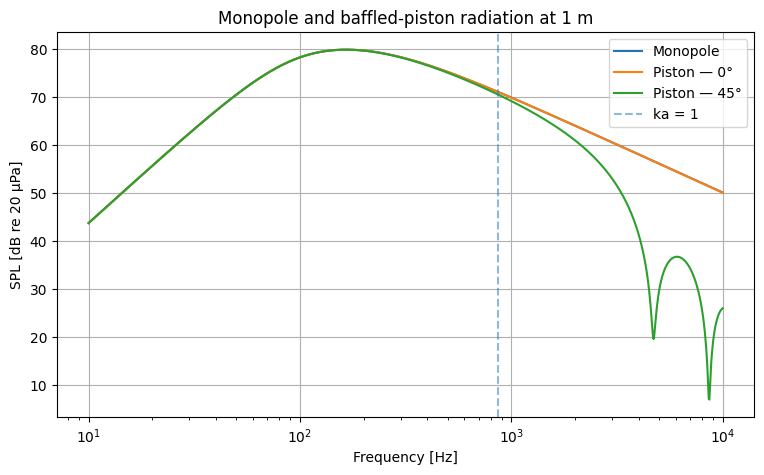

In [3]:
mono_response = sealed_monopole.solve(
    freqs,
    voltage=voltage,
    distance=distance,
)

piston_on = sealed_piston.solve(
    freqs,
    voltage=voltage,
    distance=distance,
    angle=0.0,
)

piston_45 = sealed_piston.solve(
    freqs,
    voltage=voltage,
    distance=distance,
    angle=np.deg2rad(45),
)

plt.figure()
plt.semilogx(freqs, mono_response.spl, label="Monopole")
plt.semilogx(freqs, piston_on.spl, label="Piston — 0°")
plt.semilogx(freqs, piston_45.spl, label="Piston — 45°")
plt.axvline(f_ka1, linestyle="--", alpha=0.5, label="ka = 1")

plt.xlabel("Frequency [Hz]")
plt.ylabel("SPL [dB re 20 µPa]")
plt.title("Monopole and baffled-piston radiation at 1 m")
plt.legend()
plt.show()


The on-axis piston remains close to the monopole over a broad range. Off axis, the finite piston develops high-frequency attenuation and nulls because different surface elements arrive with different phases.



# Experiment 2 — Numerical Rayleigh integral vs. analytical directivity

At a fixed off-axis angle, the analytical far-field piston model predicts nulls whenever

\[
J_1(ka\sin\theta)=0.
\]

The numerical Rayleigh integral should reproduce the same notch frequencies.


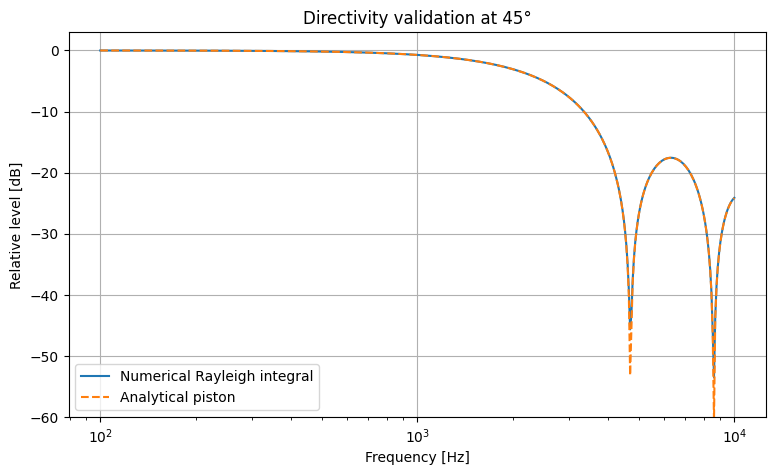

In [4]:
angle_deg = 45.0
angle = np.deg2rad(angle_deg)
validation_distance = 3.0

freq_test = np.logspace(
    np.log10(100),
    np.log10(10000),
    500,
)

velocity = sealed_piston.solve(
    freq_test,
    voltage=1.0,
    distance=validation_distance,
    angle=0.0,
).velocity

p_on = piston.pressure(
    freq=freq_test,
    velocity=velocity,
    piston_area=driver.Sd,
    distance=validation_distance,
    angle=0.0,
    medium=AIR,
)

p_off = piston.pressure(
    freq=freq_test,
    velocity=velocity,
    piston_area=driver.Sd,
    distance=validation_distance,
    angle=angle,
    medium=AIR,
)

D_num_db = magnitude_to_db(
    np.maximum(np.abs(p_off / p_on), 1e-12)
)

D_an = np.array([
    piston.analytical_directivity(
        freq=f,
        piston_area=driver.Sd,
        angles=np.array([angle]),
        medium=AIR,
    )[0]
    for f in freq_test
])

D_an_db = magnitude_to_db(
    np.maximum(np.abs(D_an), 1e-12)
)

plt.figure()
plt.semilogx(freq_test, D_num_db, label="Numerical Rayleigh integral")
plt.semilogx(freq_test, D_an_db, "--", label="Analytical piston")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Relative level [dB]")
plt.title(f"Directivity validation at {angle_deg:.0f}°")
plt.ylim(-60, 3)
plt.legend()
plt.show()


Agreement of the null locations validates the path-length geometry and phase accumulation in the numerical surface integral. Small differences in null depth are expected from finite discretization and finite receiver distance.



# Experiment 3 — Classic directivity plots

The following polar plots show the radiation pattern at several frequencies. Each curve is normalized to its own on-axis pressure.


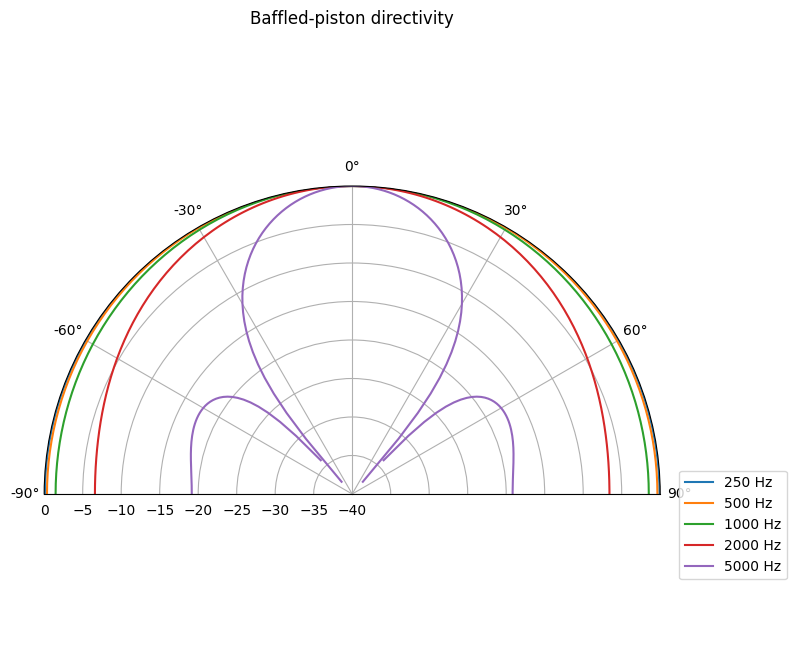

In [5]:
angles = np.deg2rad(
    np.linspace(-90, 90, 181)
)

directivity_freqs = [
    250,
    500,
    1000,
    2000,
    5000,
]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="polar")

for f0 in directivity_freqs:
    velocity = sealed_piston.solve(
        np.array([f0]),
        voltage=1.0,
        distance=validation_distance,
        angle=0.0,
    ).velocity[0]

    D = piston.directivity(
        freq=f0,
        velocity=velocity,
        piston_area=driver.Sd,
        angles=angles,
        distance=validation_distance,
        medium=AIR,
    )

    D_db = magnitude_to_db(
        np.maximum(np.abs(D), 1e-4)
    )

    ax.plot(
        angles,
        D_db,
        label=f"{f0} Hz",
    )

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetamin(-90)
ax.set_thetamax(90)
ax.set_ylim(-40, 0)
ax.set_title("Baffled-piston directivity")
ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0.1))
plt.show()


Below $ka\approx1$, radiation is broad. As $ka$ increases, the main lobe narrows and side lobes/nulls appear.



# Experiment 4 — Numerical vs. analytical angular pattern

A single-frequency angular sweep gives a direct comparison between the numerical Rayleigh integral and the analytical Bessel-function result.


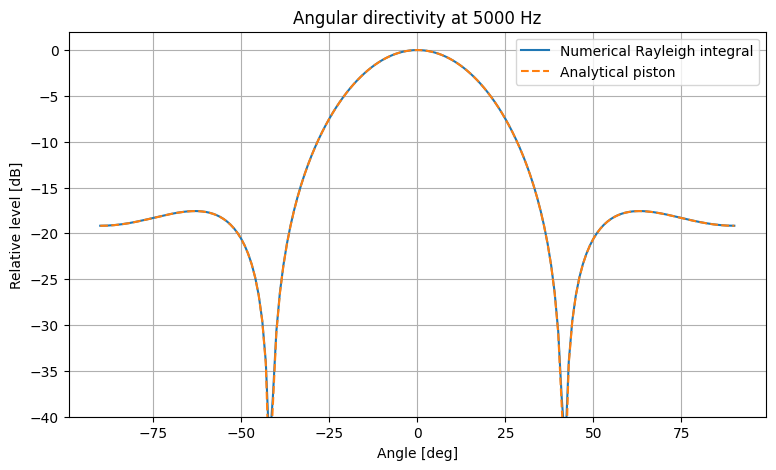

In [6]:
f_compare = 5000.0

angles_compare = np.deg2rad(
    np.linspace(-90, 90, 181)
)

velocity_compare = sealed_piston.solve(
    np.array([f_compare]),
    voltage=1.0,
    distance=validation_distance,
    angle=0.0,
).velocity[0]

D_num = piston.directivity(
    freq=f_compare,
    velocity=velocity_compare,
    piston_area=driver.Sd,
    angles=angles_compare,
    distance=validation_distance,
    medium=AIR,
)

D_an = piston.analytical_directivity(
    freq=f_compare,
    piston_area=driver.Sd,
    angles=angles_compare,
    medium=AIR,
)

D_num_db = magnitude_to_db(
    np.maximum(np.abs(D_num), 1e-4)
)

D_an_db = magnitude_to_db(
    np.maximum(np.abs(D_an), 1e-4)
)

plt.figure()
plt.plot(
    np.rad2deg(angles_compare),
    D_num_db,
    label="Numerical Rayleigh integral",
)
plt.plot(
    np.rad2deg(angles_compare),
    D_an_db,
    "--",
    label="Analytical piston",
)

plt.xlabel("Angle [deg]")
plt.ylabel("Relative level [dB]")
plt.title(f"Angular directivity at {f_compare:.0f} Hz")
plt.ylim(-40, 2)
plt.legend()
plt.show()


# Experiment 5 — Radiation field heatmaps

For one frequency, evaluate the piston over receiver distance and angle.

The **absolute SPL map**

$L_p(r,\theta)=20\log_{10}\frac{|p(r,\theta)|}{20\,\mu\mathrm{Pa}}$

contains both distance decay and angular directivity.

The **relative map**

$D(r,\theta)=20\log_{10}\frac{|p(r,\theta)|}{|p(r,0)|}$

removes the on-axis distance dependence and isolates directivity.


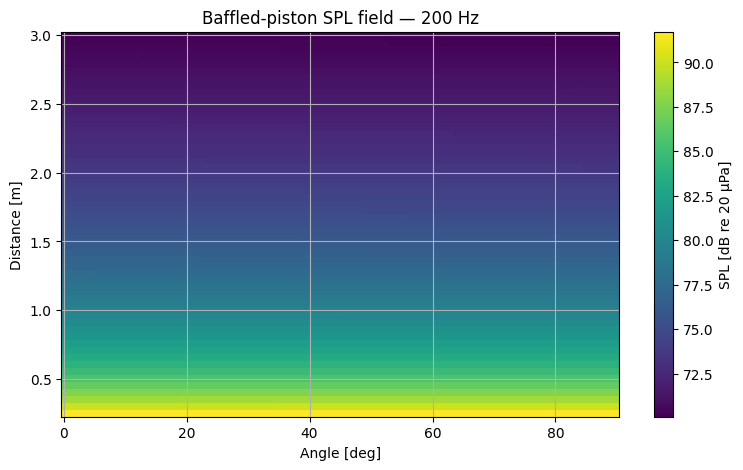

In [7]:
heatmap_frequency = 200.0

distances = np.linspace(0.25, 3.0, 55)

heatmap_angles = np.deg2rad(
    np.linspace(0, 90, 121)
)

velocity_field = sealed_piston.solve(
    np.array([heatmap_frequency]),
    voltage=1.0,
    distance=1.0,
    angle=0.0,
).velocity[0]

P = piston.pressure_field(
    freq=heatmap_frequency,
    velocity=velocity_field,
    piston_area=driver.Sd,
    distances=distances,
    angles=heatmap_angles,
    medium=AIR,
)

spl_map = magnitude_to_db(
    P,
    reference=20e-6,
)

plt.figure(figsize=(9, 5))
mesh = plt.pcolormesh(
    np.rad2deg(heatmap_angles),
    distances,
    spl_map,
    shading="auto",
)

plt.colorbar(mesh, label="SPL [dB re 20 µPa]")
plt.xlabel("Angle [deg]")
plt.ylabel("Distance [m]")
plt.title(f"Baffled-piston SPL field — {heatmap_frequency:.0f} Hz")
plt.show()

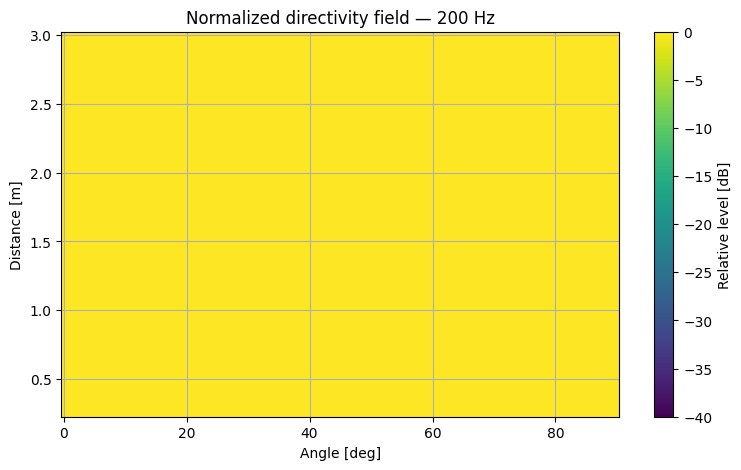

In [8]:
on_axis = np.abs(P[:, 0])[:, None]

directivity_map = magnitude_to_db(
    np.maximum(
        np.abs(P) / on_axis,
        1e-6,
    )
)

plt.figure(figsize=(9, 5))
mesh = plt.pcolormesh(
    np.rad2deg(heatmap_angles),
    distances,
    directivity_map,
    shading="auto",
    vmin=-40,
    vmax=0,
)

plt.colorbar(mesh, label="Relative level [dB]")
plt.xlabel("Angle [deg]")
plt.ylabel("Distance [m]")
plt.title(f"Normalized directivity field — {heatmap_frequency:.0f} Hz")
plt.show()

/tmp/ipykernel_5870/35674219.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = plt.pcolormesh(


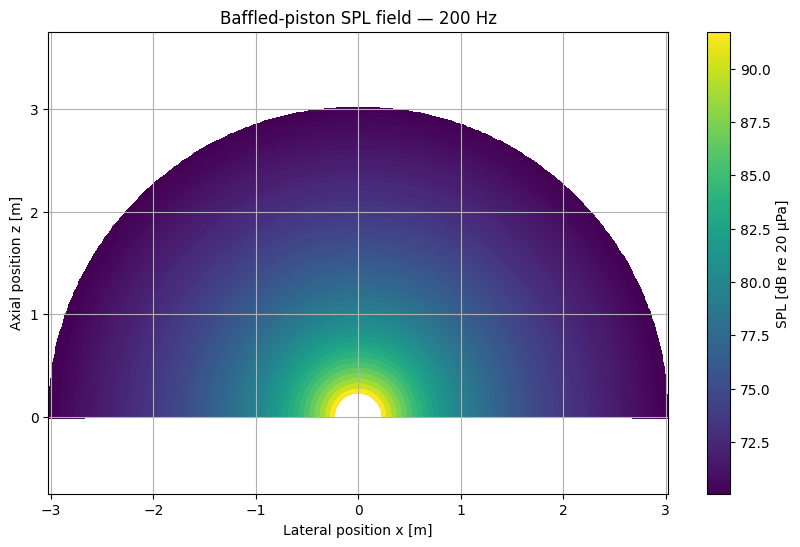

In [9]:
X, Z = piston.field_coordinates(
    distances=distances,
    angles=heatmap_angles,
)

X_full = np.concatenate(
    (-X[:, ::-1], X),
    axis=1,
)

Z_full = np.concatenate(
    (Z[:, ::-1], Z),
    axis=1,
)

SPL_full = np.concatenate(
    (spl_map[:, ::-1], spl_map),
    axis=1,
)

plt.figure(figsize=(10, 6))

mesh = plt.pcolormesh(
    X_full,
    Z_full,
    SPL_full,
    shading="auto",
)

plt.colorbar(mesh, label="SPL [dB re 20 µPa]")
plt.xlabel("Lateral position x [m]")
plt.ylabel("Axial position z [m]")
plt.title(f"Baffled-piston SPL field — {heatmap_frequency:.0f} Hz")
plt.axis("equal")
plt.show()

/tmp/ipykernel_5870/546411109.py:8: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = plt.pcolormesh(


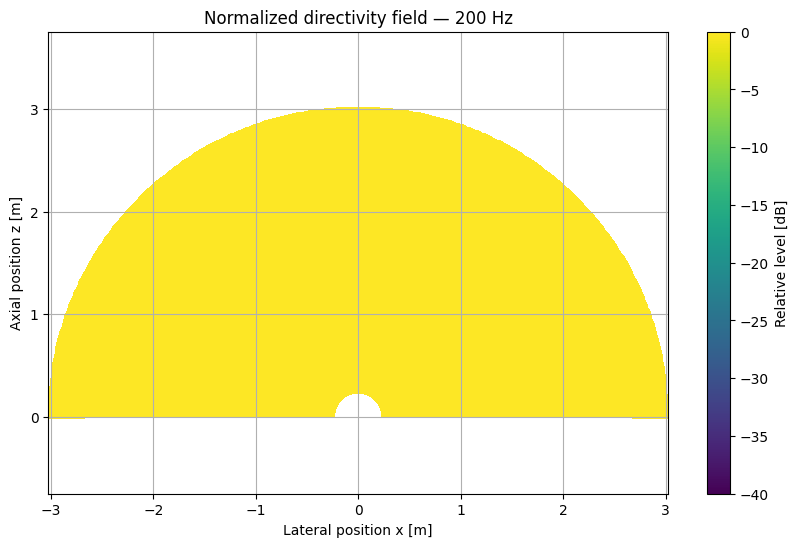

In [10]:
directivity_full = np.concatenate(
    (directivity_map[:, ::-1], directivity_map),
    axis=1,
)

plt.figure(figsize=(10, 6))

mesh = plt.pcolormesh(
    X_full,
    Z_full,
    directivity_full,
    shading="auto",
    vmin=-40,
    vmax=0,
)

plt.colorbar(mesh, label="Relative level [dB]")
plt.xlabel("Lateral position x [m]")
plt.ylabel("Axial position z [m]")
plt.title(f"Normalized directivity field — {heatmap_frequency:.0f} Hz")
plt.axis("equal")
plt.show()

## Summary

- At low \(ka\), the piston approaches the monopole.
- Off-axis phase differences produce attenuation and nulls as \(ka\) increases.
- The numerical Rayleigh model reproduces the analytical circular-piston directivity.
- Polar plots show the progressive narrowing of the radiation pattern.
- Pressure-field and coordinate calculations now live in `BaffledCircularPiston`; the notebook is responsible only for plotting and interpretation.